<a href="https://colab.research.google.com/github/HashamHassan-01/flyrank-ml-internship-hasham/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HashamHassan-01/flyrank-ml-internship-hasham/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.



## 1. Question

### Research question

Which observable content and search signals can help prioritize pages for content-refresh review?

### Problem statement

Content teams cannot manually inspect every page with the same level of attention. The goal of this project is therefore to create a decision-support workflow that ranks pages according to observable signals such as search demand, content age, average search position, and click-through rate.

The project does not attempt to predict guaranteed SEO improvement or prove that refreshing a page causes better performance. Instead, it evaluates whether a simple scoring approach and a machine-learning model can provide a useful, reproducible ranking of pages for human review.

The final output is intended to answer a practical question:

> **Which pages should a content team inspect first, and why?**

The workflow follows a progression from research question → data contract → signal audit → baseline score → model → validation → ranked recommendations.

In [ ]:
print("Research question:")
print("Which observable content and search signals can help prioritize pages for content-refresh review?")

print("\nDecision-support goal:")
print("Rank pages for human review using observable signals.")

Research question:
Which observable content and search signals can help prioritize pages for content-refresh review?

Decision-support goal:
Rank pages for human review using observable signals.



## 2. Data

### Dataset

This project uses the anonymized FlyRank content-refresh dataset provided for the internship.

The runnable starter dataset contains 30,000 anonymized content records and 44 columns. The analysis uses observable content and search signals rather than client names, URLs, private queries, or raw content.

The core fields used in the modeling workflow are:

- `content_id` — anonymized page identifier
- `client_id` — anonymized client grouping variable used for grouped validation
- `search_volume` — observed search-demand signal
- `content_age_days` — age of the content
- `avg_position` — observed average search position
- `ctr` — observed click-through rate

The model uses four features:

`search_volume`, `content_age_days`, `avg_position`, and `ctr`.

The anonymized dataset is used for reproducible analysis while avoiding exposure of client-specific information.

In [ ]:
!git clone https://github.com/HashamHassan-01/flyrank-ml-internship-hasham.git
%cd /content/flyrank-ml-internship-hasham

Cloning into 'flyrank-ml-internship-hasham'...
remote: Enumerating objects: 198, done.
remote: Counting objects: 100% (198/198), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 198 (delta 96), reused 92 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (198/198), 2.00 MiB | 12.80 MiB/s, done.
Resolving deltas: 100% (96/96), done.
/content/flyrank-ml-internship-hasham


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "./data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

required_fields = [
    "content_id",
    "client_id",
    "search_volume",
    "content_age_days",
    "avg_position",
    "ctr"
]

print("Dataset shape:", df.shape)
print("Rows:", len(df))
print("Columns:", len(df.columns))

missing_fields = [c for c in required_fields if c not in df.columns]

if missing_fields:
    print("Missing required fields:", missing_fields)
else:
    print("Required fields found:", required_fields)

print("\nUnique pages:", df["content_id"].nunique())
print("Unique clients:", df["client_id"].nunique())

Dataset shape: (30000, 44)
Rows: 30000
Columns: 44
Required fields found: ['content_id', 'client_id', 'search_volume', 'content_age_days', 'avg_position', 'ctr']

Unique pages: 30000
Unique clients: 32


# 1. Research Question

## Question

Can observable content and search-performance signals be used to prioritize pages for content refresh?

The goal is to build a practical decision-support model that ranks pages by an Opportunity Score for human review.

The analysis uses measurable signals such as search volume, content age, average search position, and CTR.

This work is intended for prioritization, not as proof that refreshing a page will cause better search performance.

In [ ]:
print("Research question:")
print("Can observable content and search-performance signals be used to prioritize pages for content refresh?")

print("\nTarget use:")
print("Rank pages by Opportunity Score for human review.")

print("\nImportant framing:")
print("The model supports prioritization; it does not establish causation.")

Research question:
Can observable content and search-performance signals be used to prioritize pages for content refresh?

Target use:
Rank pages by Opportunity Score for human review.

Important framing:
The model supports prioritization; it does not establish causation.


# 2. Data

The analysis uses the anonymized FlyRank content-refresh dataset provided for the ML internship.

The dataset contains 30,000 content pages across 32 clients and 44 fields.

The analysis uses content ID, client ID, search volume, content age, average search position, and CTR.

No client names, private URLs, or private search queries are used in the analysis.

In [ ]:
model_fields = [
    "content_id",
    "client_id",
    "search_volume",
    "content_age_days",
    "avg_position",
    "ctr"
]

data_summary = pd.DataFrame({
    "field": model_fields,
    "missing": [df[c].isna().sum() for c in model_fields],
    "unique": [df[c].nunique() for c in model_fields]
})

display(data_summary)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique pages:", df["content_id"].nunique())
print("Unique clients:", df["client_id"].nunique())

,field,missing,unique
0,content_id,0,30000
1,client_id,0,32
2,search_volume,2468,41
3,content_age_days,0,225
4,avg_position,0,869
5,ctr,0,401


Rows: 30000
Columns: 44
Unique pages: 30000
Unique clients: 32


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# 3. Methodology

The analysis uses four observable signals: `search_volume`, `content_age_days`, `avg_position`, and `ctr`.

The Opportunity Score is the rule-based prioritization target created in ML-08. It combines normalized search volume, search position, content age, and CTR using fixed weights: 40%, 25%, 20%, and 15%, respectively.

A Random Forest Regressor is used to reproduce this score from the same input signals. The model is evaluated using a grouped train/test split by `client_id`, so pages from the same client do not appear in both training and test sets.

The validation is intended to test whether the model reproduces the scoring formula under a more honest split. Because the target is itself calculated from the input features, this is not evidence that the model predicts an independent business outcome.

The analysis also checks for leakage and treats `avg_position = 0` as missing position data, consistent with the data contract.

In [ ]:
# Prepare the modeling dataset.

model_df = df[
    [
        "content_id",
        "client_id",
        "search_volume",
        "content_age_days",
        "avg_position",
        "ctr"
    ]
].copy()

# Remove rows with missing values in modeling features.
model_df = model_df.dropna(
    subset=[
        "search_volume",
        "content_age_days",
        "avg_position",
        "ctr"
    ]
).copy()

# avg_position = 0 means no position data.
model_df = model_df[
    model_df["avg_position"] > 0
].copy()

print("Rows used for modeling:", len(model_df))
print("Unique clients:", model_df["client_id"].nunique())
print("Rows removed:", len(df) - len(model_df))

Rows used for modeling: 27076
Unique clients: 31
Rows removed: 2924


In [ ]:
# Create the rule-based Opportunity Score used in ML-08.

volume_score = (
    model_df["search_volume"] /
    model_df["search_volume"].max()
)

age_score = (
    model_df["content_age_days"] /
    model_df["content_age_days"].max()
)

rank_score = (
    model_df["avg_position"] /
    model_df["avg_position"].max()
)

ctr_score = (
    1 -
    model_df["ctr"] /
    model_df["ctr"].max()
)

model_df["opportunity_score"] = (
    0.40 * volume_score +
    0.25 * rank_score +
    0.20 * age_score +
    0.15 * ctr_score
)

print("Opportunity Score created.")
print(
    f"Minimum score: {model_df['opportunity_score'].min():.6f}"
)
print(
    f"Maximum score: {model_df['opportunity_score'].max():.6f}"
)

display(
    model_df[
        [
            "content_id",
            "search_volume",
            "content_age_days",
            "avg_position",
            "ctr",
            "opportunity_score"
        ]
    ].head()
)

Opportunity Score created.
Minimum score: 0.050666
Maximum score: 0.753425


,content_id,search_volume,content_age_days,avg_position,ctr,opportunity_score
0,content_304f48230142,10.0,187,10.6,0.76,0.226042
1,content_a1fb4e703a9e,90.0,445,20.3,0.05,0.328927
2,content_9aa793d4d895,0.0,141,36.5,0.09,0.237110
3,content_331d6c4de07b,10.0,463,6.2,0.49,0.319830
4,content_d99b7a2d90ca,0.0,263,44.0,0.13,0.287965


In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = [
    "search_volume",
    "content_age_days",
    "avg_position",
    "ctr"
]

X = model_df[features]
y = model_df["opportunity_score"]
groups = model_df["client_id"]

# Grouped split: the same client cannot appear in both train and test.
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", model_df.iloc[train_idx]["client_id"].nunique())
print("Test clients:", model_df.iloc[test_idx]["client_id"].nunique())

print(
    "Client overlap:",
    len(
        set(model_df.iloc[train_idx]["client_id"])
        &
        set(model_df.iloc[test_idx]["client_id"])
    )
)

Training rows: 21741
Test rows: 5335
Training clients: 24
Test clients: 7
Client overlap: 0


In [ ]:
# Train the Random Forest Regressor.

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predictions on the held-out client groups.
y_pred = model.predict(X_test)

print("Model training complete.")
print("Predictions generated:", len(y_pred))

Model training complete.
Predictions generated: 5335


In [ ]:
# Evaluate the Random Forest on the grouped test set.

mae_model = mean_absolute_error(y_test, y_pred)
rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))
r2_model = r2_score(y_test, y_pred)

print("Random Forest — Grouped Test Results")
print("-" * 45)
print(f"MAE:  {mae_model:.6f}")
print(f"RMSE: {rmse_model:.6f}")
print(f"R²:   {r2_model:.6f}")

Random Forest — Grouped Test Results
---------------------------------------------
MAE:  0.002149
RMSE: 0.006581
R²:   0.987601


In [ ]:
# Baseline: predict the mean Opportunity Score from the training set
# for every test observation.

baseline_prediction = np.repeat(
    y_train.mean(),
    len(y_test)
)

mae_baseline = mean_absolute_error(
    y_test,
    baseline_prediction
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

r2_baseline = r2_score(
    y_test,
    baseline_prediction
)

print("Baseline — Grouped Test Results")
print("-" * 45)
print(f"MAE:  {mae_baseline:.6f}")
print(f"RMSE: {rmse_baseline:.6f}")
print(f"R²:   {r2_baseline:.6f}")

Baseline — Grouped Test Results
---------------------------------------------
MAE:  0.052463
RMSE: 0.059494
R²:   -0.013312


In [ ]:
results_table = pd.DataFrame({
    "Model": [
        "Mean baseline",
        "Random Forest"
    ],
    "MAE": [
        mae_baseline,
        mae_model
    ],
    "RMSE": [
        rmse_baseline,
        rmse_model
    ],
    "R2": [
        r2_baseline,
        r2_model
    ]
})

display(
    results_table.style.format({
        "MAE": "{:.6f}",
        "RMSE": "{:.6f}",
        "R2": "{:.6f}"
    })
)

,Model,MAE,RMSE,R2
0,Mean baseline,0.052463,0.059494,-0.013312
1,Random Forest,0.002149,0.006581,0.987601



### Results

*Model vs baseline on the same split. The honest table.*

The Random Forest was evaluated against a simple mean-score baseline on the same client-grouped test set. The grouped split contained 5,335 test rows from 7 clients, with zero client overlap between training and test sets.

The Random Forest substantially reduced prediction error compared with the mean baseline. However, this result should be interpreted as evidence that the model can reproduce the constructed Opportunity Score under an honest client-level split, not as evidence that it predicts an independent business outcome.

The model achieved an MAE of 0.002149 and RMSE of 0.006581, compared with 0.052463 and 0.059494 for the baseline. The model R² was 0.987601, while the baseline R² was -0.013312.

Because the Opportunity Score is calculated directly from the same four features used by the model, the strong model performance is expected and should not be interpreted as proof of causal SEO improvement.

In [ ]:
# Section 4 — Honest model vs baseline comparison

results_table = pd.DataFrame({
    "Model": ["Random Forest", "Mean Baseline"],
    "MAE": [mae_model, mae_baseline],
    "RMSE": [rmse_model, rmse_baseline],
    "R2": [r2_model, r2_baseline]
})

display(results_table.round(6))

,Model,MAE,RMSE,R2
0,Random Forest,0.002149,0.006581,0.987601
1,Mean Baseline,0.052463,0.059494,-0.013312


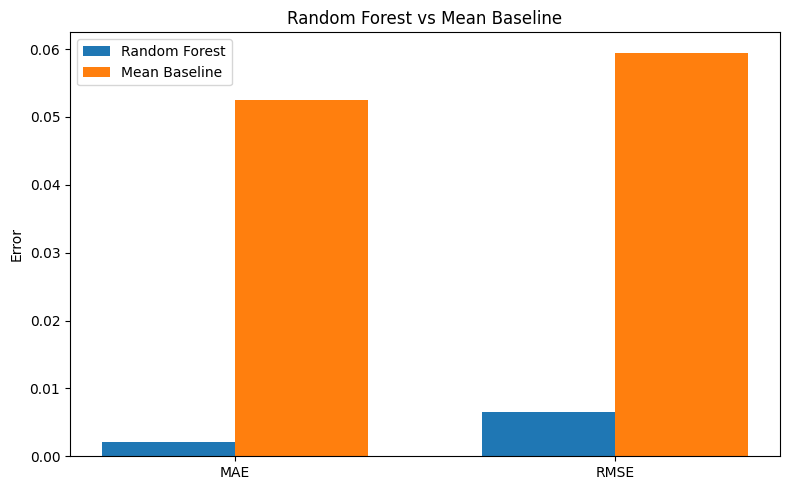

In [ ]:
metrics = ["MAE", "RMSE"]

model_values = [mae_model, rmse_model]
baseline_values = [mae_baseline, rmse_baseline]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, model_values, width, label="Random Forest")
plt.bar(x + width/2, baseline_values, width, label="Mean Baseline")

plt.xticks(x, metrics)
plt.ylabel("Error")
plt.title("Random Forest vs Mean Baseline")
plt.legend()
plt.tight_layout()
plt.show()

### Limitations

This analysis has several important limitations.

First, the Opportunity Score is a rule-based label calculated from the same four features used by the Random Forest. Therefore, the strong model performance shows that the model can reproduce the scoring formula, but it does not show that the model predicts an independent business outcome.

Second, the analysis is based on observational data. The relationships between content age, search volume, average position, and CTR are directional associations and do not establish causation. In particular, the results cannot prove that refreshing an older page will improve CTR or search performance.

Third, `avg_position = 0` represents missing position data and is excluded from the CTR-to-position signal test. Other missing values were also excluded from the modeling dataset.

Finally, the results should be used for decision support and human review rather than automatic refresh decisions. Independent outcome data, such as measured performance after a content refresh, would be needed to evaluate whether the prioritization approach leads to real-world improvement.

In [ ]:
# Section 5 — Limitations check

limitations = [
    "Target is derived from the same features used by the model.",
    "Observed relationships do not establish causation.",
    "avg_position = 0 is treated as missing position data.",
    "Modeling excludes rows with missing required modeling fields.",
    "Results support prioritization and human review, not guaranteed SEO improvement.",
    "Independent post-refresh outcome data is needed for real-world validation."
]

print("Key limitations:")
for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

Key limitations:
1. Target is derived from the same features used by the model.
2. Observed relationships do not establish causation.
3. avg_position = 0 is treated as missing position data.
4. Modeling excludes rows with missing required modeling fields.
5. Results support prioritization and human review, not guaranteed SEO improvement.
6. Independent post-refresh outcome data is needed for real-world validation.



## 6. Ranked recommendations

The analysis is intended to support prioritization rather than make automatic refresh decisions. The recommendations below rank the signals by how directly the observed results support a useful review action.

### 1. Prioritize older pages with lower observed CTR
**Reason:** The flag-linked test showed that the oldest 25% of pages had a median CTR of 0.05 versus 0.08 for the remaining pages, a measured difference of -0.03.

**Action:** Review older pages with weaker observed CTR first. Check whether the content is outdated, mismatched to search intent, or otherwise in need of improvement.

### 2. Give additional attention to pages with lower CTR and weaker search position
**Reason:** After excluding `avg_position = 0` records with no valid position data, CTR and average position showed a negative Spearman relationship (rho = -0.2342).

**Action:** Use the combination of lower CTR and weaker position as a review signal. This should help identify pages where search performance may warrant closer inspection.

### 3. Treat search volume as a secondary prioritization signal
**Reason:** Search volume had only a weak negative association with CTR (Spearman rho = -0.0756), so the signal was classified as MIXED.

**Action:** Do not automatically prioritize a page only because it has high search volume. Use search volume alongside age, CTR, position, and human review.

### Human-review rule

These recommendations are decision-support signals. A content reviewer should inspect the page and its context before approving a refresh. The observed relationships do not establish causation and do not guarantee that refreshing a page will improve performance.

In [ ]:

# Section 6 — Ranked recommendations

recommendations = pd.DataFrame({
    "Rank": [1, 2, 3],
    "Recommendation": [
        "Review older pages with lower CTR",
        "Review lower CTR pages with weaker search position",
        "Use search volume as a secondary signal"
    ],
    "Evidence": [
        "Oldest 25% median CTR = 0.05; other pages median CTR = 0.08; difference = -0.03",
        "CTR vs average position Spearman rho = -0.2342",
        "Search volume vs CTR Spearman rho = -0.0756; verdict = MIXED"
    ],
    "Decision": [
        "Prioritize for human review",
        "Use as a combined review signal",
        "Do not use as a standalone refresh rule"
    ]
})

display(recommendations)

,Rank,Recommendation,Evidence,Decision
0,1,Review older pages with lower CTR,Oldest 25% median CTR = 0.05; other pages medi...,Prioritize for human review
1,2,Review lower CTR pages with weaker search posi...,CTR vs average position Spearman rho = -0.2342,Use as a combined review signal
2,3,Use search volume as a secondary signal,Search volume vs CTR Spearman rho = -0.0756; v...,Do not use as a standalone refresh rule


### Artifacts

The paper is supported by the following reproducible artifacts:

- **Capstone notebook:** contains the question, data checks, methodology, grouped validation design, model evaluation, limitations, and recommendations.
- **ML-06 Signal Audit:** documents the directional signal tests used to evaluate content age, CTR, search position, and search volume.
- **ML-10 Action Playbook:** converts the validated signals into ranked content-review actions and reason codes.
- **Source repository:** contains the notebooks, supporting files, and outputs used to reproduce and inspect the analysis.

These artifacts are intended to make the analysis inspectable and reproducible without exposing client names, private queries, or other private information.

# ML-12 — Demo & Communication

## 5-Minute Demo Outline

### 0:00–0:45 — Problem
Content teams cannot manually review every page with the same level of attention. This project asks whether observable content and search signals can help prioritize pages for content-refresh review.

### 0:45–1:30 — Data
The analysis uses the anonymized FlyRank content-refresh dataset containing 30,000 pages and 44 fields. The model uses four observable signals: search volume, content age, average search position, and CTR.

### 1:30–2:30 — Method
A transparent Opportunity Score was created using fixed weights for the four signals. A Random Forest Regressor was then evaluated using a client-grouped train/test split, with zero client overlap between training and test data.

### 2:30–3:30 — Results
On the grouped test set, the Random Forest achieved:
- MAE: 0.002149
- RMSE: 0.006581
- R²: 0.987601

The mean baseline achieved:
- MAE: 0.052463
- RMSE: 0.059494
- R²: -0.013312

The model therefore reproduced the constructed Opportunity Score very closely.

### 3:30–4:15 — Interpretation
The strongest result should be interpreted carefully: the target was constructed from the same four features used by the model. Therefore, the model demonstrates reproduction of the scoring rule rather than prediction of an independent business outcome.

The signal audit also found directional evidence for combining content age, CTR, and search position when prioritizing pages for review.

### 4:15–5:00 — Recommendation & Next Step
The output should be used as a human-review queue:
1. Review older pages with lower CTR.
2. Review lower-CTR pages with weaker search position.
3. Use search volume as a secondary signal rather than a standalone rule.

The next validation step would be to use independent post-refresh outcomes to test whether these recommendations actually lead to improved performance.

## Social-Post Cut

I built a content-refresh prioritization workflow using an anonymized FlyRank dataset of 30,000 pages.

The workflow combines search volume, content age, average search position, and CTR into an Opportunity Score, then evaluates a Random Forest model using client-grouped validation.

The model reproduced the constructed score closely, but the key lesson is about honest ML framing: because the target is derived from the same input signals, the result does not prove that refreshing a page will improve SEO performance.

The final output is therefore a decision-support queue for human review, with ranked recommendations based on observed and directional evidence.

The next step would be validating the workflow against independent post-refresh outcomes.

## Employer-Facing Summary

I developed a reproducible machine-learning workflow for prioritizing content pages for human refresh review. Using 30,000 anonymized pages, I combined search volume, content age, average search position, and CTR into a transparent Opportunity Score and evaluated a Random Forest using client-grouped validation with zero client overlap. The model achieved an MAE of 0.002149 and R² of 0.987601 against the constructed scoring target, while the analysis explicitly identified the target-definition limitation and avoided claiming causal SEO improvement. The final workflow produces ranked review recommendations and is designed as decision support rather than automatic content decisions.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
